[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/Quantlets/Ch_07/ATS_ch7_seminar/ATS_ch7_seminar.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 7: Regime-switching models

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 7; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> Quantlet `ATS_ch7_seminar`: student version of the Seminar 7 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The numpy engine of Chapter 7, the data loaders and the functions of the solved tasks.

In [ ]:
import math
SEED = 2026
RO_HICP = ('prc_hicp_minr', 'M.I25.TOTAL.RO')
RO_GDP = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
US = {'start': '1947-04-01', 'est_end': '2019-10-01', 'ham_start': '1952-04-01', 'end': '2026-04-01'}
MARKET = {'start': '2000-01-01', 'end': '2026-09-18'}
EVENTS_EURRON = [('2005-07-01', 'RON redenomination'), ('2008-10-01', 'October 2008'), ('2025-05-01', 'May 2025')]
_FILES = {}
A1 = {'P': [[0.9, 0.1], [0.25, 0.75]], 'mu': [1.0, -1.0], 'sigma': 1.0, 'y': [0.5, -1.5]}
A3 = {'y': [1.2, 0.8, -0.9, -1.4, 0.6], 'xi': [0.9, 0.8, 0.1, 0.05, 0.7], 'J11': [0.75, 0.08, 0.04, 0.05]}
A4 = {'h': (1, 4, 12)}
A5 = {'T': 200, 'll': [-310.4, -296.1, -292.8], 'npar': [3, 7, 13], 'B': 199, 'exceed': 6}
A6 = {'K': (2, 3), 'p': 4}
A7 = {'omega': (0.02, 0.2), 'alpha': (0.05, 0.1), 'beta': (0.9, 0.8), 'h_prev': (0.5, 2.0), 'e_prev': 1.5, 'xi': (0.7, 0.3)}
A8 = {'n11': 46, 'n12': 4, 'a': 8.0, 'b': 2.0, 'nj': 30, 'ybar': 0.9, 'sig2': 0.25, 'm0': 0.0, 'v0': 10.0}


def read_ecb(flow, key, start=None):
    """One series from the ECB Data Portal (public SDMX REST API, CSV), e.g. the monthly USD/EUR reference rate:
        read_ecb('EXR', 'M.USD.EUR.SP00.A')
    or the euro-area HICP annual rate of change: read_ecb('ICP', 'M.U2.N.000000.4.ANR')."""
    url = (f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}?format=csvdata'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('ecb', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{flow}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def cached(key, fn):
    if key not in _FILES:
        _FILES[key] = fn()
    return _FILES[key]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def hamilton_gnp():
    """Hamilton's (1989) data: 100 x change of log real GNP, 1951Q2-1984Q4 (as distributed with statsmodels)."""
    from statsmodels.tsa.regime_switching.tests.test_markov_autoregression import rgnp
    return pd.Series(np.asarray(rgnp, float), index=pd.period_range('1951Q2', periods=len(rgnp), freq='Q').to_timestamp(),
                     name='rgnp')


def filardo_data():
    """Filardo's (1994) data: monthly growth of US industrial production (dlip) and of the composite leading indicator
    (dmdlleading), 1948-1991 (as distributed with statsmodels)."""
    import statsmodels
    p = os.path.join(os.path.dirname(statsmodels.__file__), 'tsa', 'regime_switching', 'tests', 'results', 'mar_filardo.csv')
    d = pd.read_csv(p)[['dlip', 'dmdlleading']]
    d.index = pd.date_range('1948-01-01', periods=len(d), freq='MS')
    return d


def us_gdp():
    """US real GDP growth (100 x change of log GDPC1, % per quarter) and the NBER recession quarters (USRECQ)."""
    def get():
        g = read_fred('GDPC1')
        y = (100 * np.log(g).diff()).dropna().rename('gdp')
        rec = read_fred('USRECQ').reindex(y.index).fillna(0).astype(int)
        return y, rec
    return cached('us_gdp', get)


def us_unemp_q():
    return cached('us_u', lambda: read_fred('UNRATE').resample('QS').mean())


def ro_gdp():
    g = cached('ro_gdp', lambda: read_eurostat(*RO_GDP))
    return (100 * np.log(g).diff()).dropna().rename('ro_gdp')


def ro_inflation():
    """Romanian annual HICP inflation, 100 x log(P_t / P_{t-12}), monthly from January 1997."""
    p = cached('ro_hicp', lambda: read_eurostat(*RO_HICP))
    return (100 * np.log(p).diff(12)).dropna().rename('ro_infl')


def weekly_returns(name, start=MARKET['start'], end=MARKET['end']):
    """Weekly log returns (%), Friday closes (last trading day of each week)."""
    p = load_close(name, start, end).resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff()).dropna().rename(name)


def eurron_daily():
    """EUR/RON: ECB euro reference rate for the leu before July 2005 (old lei rescaled to RON), official BNR reference
    rate from 1 July 2005 (redenomination)."""
    def get():
        ecb = read_ecb('EXR', 'D.RON.EUR.SP00.A').loc[:'2005-06-30']
        bnr = read_reference_rate('EUR', start='2005-07-01')
        return pd.concat([ecb, bnr]).sort_index().rename('eurron')
    return cached('eurron', get)


def shade(ax, ind, color=st.Amber, alpha=0.2):
    """Shade the periods where the 0/1 indicator equals 1 (date index)."""
    ind = ind.astype(int)
    on = False
    idx = ind.index
    for i, v in enumerate(ind.values):
        if v and not on:
            s, on = idx[i], True
        if on and (not v or i == len(ind) - 1):
            ax.axvspan(s, idx[i], color=color, alpha=alpha, lw=0, label='_shade')
            on = False


def patch(color, alpha=0.2):
    from matplotlib.patches import Patch
    return Patch(color=color, alpha=alpha)


def ergodic(P):
    """Ergodic (stationary) probabilities of a transition matrix P[i, j] = Pr(S_t = j | S_{t-1} = i):
    the left eigenvector of P for the eigenvalue 1, i.e. the solution of pi' P = pi', sum(pi) = 1."""
    M = P.shape[0]
    A = np.vstack([P.T - np.eye(M), np.ones(M)])
    b = np.r_[np.zeros(M), 1.0]
    return np.linalg.lstsq(A, b, rcond=None)[0]


def durations(P):
    """Expected duration of each regime, 1 / (1 - p_ii)."""
    return 1.0 / (1.0 - np.diag(P))


def simulate_chain(P, T, rng, s0=None):
    M = P.shape[0]
    s = np.empty(T, dtype=int)
    s[0] = rng.choice(M, p=ergodic(P)) if s0 is None else s0
    u = rng.random(T)
    cum = np.cumsum(P, axis=1)
    for t in range(1, T):
        s[t] = min(int(np.searchsorted(cum[s[t - 1]], u[t])), M - 1)
    return s


def hamilton_filter(logf, P, xi1=None):
    """Hamilton filter.
    logf : T x M array, log f(y_t | S_t = j, Y_{t-1}) for each regime j;
    P    : M x M transition matrix (rows sum to 1) or T x M x M array, P[t] the transition from t-1 to t;
    xi1  : Pr(S_1 = j | Y_0), the ergodic probabilities by default.
    Returns pred (xi_{t|t-1}), filt (xi_{t|t}), the log-likelihood and its contributions log f(y_t | Y_{t-1})."""
    T, M = logf.shape
    tv = P.ndim == 3
    pred = np.empty((T, M))
    filt = np.empty((T, M))
    llt = np.empty(T)
    xi = ergodic(P[0] if tv else P) if xi1 is None else np.asarray(xi1, float)
    for t in range(T):
        if t > 0:
            xi = filt[t - 1] @ (P[t] if tv else P)          # prediction: xi_{t|t-1} = P' xi_{t-1|t-1}
        pred[t] = xi
        m = logf[t].max()
        w = xi * np.exp(logf[t] - m)                         # xi_{t|t-1} * f_j(y_t), scaled by exp(-m)
        s = w.sum()
        llt[t] = m + np.log(s)                               # log f(y_t | Y_{t-1}) = log sum_j xi_j f_j
        filt[t] = w / s                                      # Bayes update
    return dict(pred=pred, filt=filt, loglik=float(llt.sum()), llt=llt)


def kim_smoother(filt, pred, P):
    """Kim (1994) smoother: smoothed probabilities xi_{t|T} and joint smoothed probabilities
    Pr(S_{t-1} = i, S_t = j | Y_T) (stored in joint[t], t >= 1), from
    Pr(S_t = i, S_{t+1} = j | Y_T) = xi_{t|t}(i) p_ij xi_{t+1|T}(j) / xi_{t+1|t}(j)."""
    T, M = filt.shape
    tv = P.ndim == 3
    sm = np.empty((T, M))
    joint = np.zeros((T, M, M))
    sm[-1] = filt[-1]
    for t in range(T - 2, -1, -1):
        Pn = P[t + 1] if tv else P
        ratio = np.divide(sm[t + 1], pred[t + 1], out=np.zeros(M), where=pred[t + 1] > 0)
        J = filt[t][:, None] * Pn * ratio[None, :]
        sm[t] = J.sum(axis=1)
        joint[t + 1] = J
    return sm, joint


def ffbs(filt, P, rng):
    """Forward filtering, backward sampling (Chib 1996): one draw of the whole regime path S_1..S_T from
    p(S | Y, theta) = p(S_T | Y) prod_t p(S_t | S_{t+1}, Y_t), with p(S_t = i | S_{t+1} = j, Y_t) prop. to xi_{t|t}(i) p_ij."""
    T, M = filt.shape
    tv = P.ndim == 3
    s = np.empty(T, dtype=int)
    u = rng.random(T)
    s[-1] = min(int(np.searchsorted(np.cumsum(filt[-1]), u[-1])), M - 1)
    for t in range(T - 2, -1, -1):
        Pn = P[t + 1] if tv else P
        w = filt[t] * Pn[:, s[t + 1]]
        s[t] = min(int(np.searchsorted(np.cumsum(w / w.sum()), u[t])), M - 1)
    return s


def lag_design(y, p, const=True):
    """Response y_t and regressors (1, y_{t-1}, ..., y_{t-p}) for t = p, ..., T-1."""
    y = np.asarray(y, float)
    X = [y[p - k:len(y) - k] for k in range(1, p + 1)]
    if const:
        X = [np.ones(len(y) - p)] + X
    return y[p:], (np.column_stack(X) if X else np.empty((len(y) - p, 0)))


def msr_logf(y, X, beta, sig2):
    """log N(y_t; x_t' beta_j, sigma2_j) for each regime: beta is K x k, sig2 has K entries."""
    mu = X @ beta.T                                                  # T x K
    return -0.5 * (np.log(2 * np.pi * sig2)[None, :] + (y[:, None] - mu) ** 2 / sig2[None, :])


def _wls_shared(y, X, W, sig2, switch):
    """M-step for coefficients when some are switching (switch[k] True) and others common to all regimes:
    weighted least squares on the stacked design, weights W[t, j] / sigma2_j."""
    T, k = X.shape
    K = W.shape[1]
    sw = np.where(switch)[0]
    ns = np.where(~np.asarray(switch))[0]
    npar = len(ns) + K * len(sw)
    A = np.zeros((npar, npar))
    b = np.zeros(npar)
    for j in range(K):
        D = np.zeros((T, npar))
        D[:, :len(ns)] = X[:, ns]
        D[:, len(ns) + j * len(sw):len(ns) + (j + 1) * len(sw)] = X[:, sw]
        w = W[:, j] / sig2[j]
        A += D.T @ (D * w[:, None])
        b += D.T @ (w * y)
    th = np.linalg.solve(A, b)
    beta = np.zeros((K, k))
    for j in range(K):
        beta[j, ns] = th[:len(ns)]
        beta[j, sw] = th[len(ns) + j * len(sw):len(ns) + (j + 1) * len(sw)]
    return beta


def em_msr(y, X, K, switch=None, switch_var=True, P0=None, beta0=None, sig20=None, maxit=1000, tol=1e-8,
           P_mask=None, rng=None, var_floor=1e-6, xi1_fixed=None):
    """EM algorithm of Hamilton (1990) for y_t = x_t' beta_{S_t} + e_t, e_t ~ N(0, sigma2_{S_t}).
    switch     : boolean mask of the switching coefficients (default: all switch);
    switch_var : regime-specific variances (True) or a common variance;
    P_mask     : optional 0/1 mask of allowed transitions (e.g. an upper-triangular change-point model, Chib 1998);
    xi1_fixed  : a fixed distribution of S_1 (e.g. (1, 0, ..., 0) for a change-point model), otherwise estimated.
    E-step: Hamilton filter + Kim smoother. M-step: p_ij = sum_t Pr(S_{t-1}=i, S_t=j|Y_T) / sum_t Pr(S_{t-1}=i|Y_T);
    weighted least squares for beta_j with weights xi_{t|T}(j); sigma2_j = weighted mean of squared residuals.
    The distribution of S_1 is a free parameter, estimated by xi_{1|T} (Hamilton 1990): then each EM step cannot lower
    the likelihood. The final likelihood is reported both with this estimate and with the ergodic distribution."""
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    T, k = X.shape
    switch = np.ones(k, bool) if switch is None else np.asarray(switch, bool)
    rng = rng or np.random.default_rng(0)
    if beta0 is None:
        b_ols = np.linalg.lstsq(X, y, rcond=None)[0]
        s_ols = np.std(y - X @ b_ols)
        beta = np.tile(b_ols, (K, 1))
        if switch_var and rng.random() < 0.5:        # a start that separates the regimes by their variances
            sig2 = s_ols ** 2 * np.geomspace(0.2, 2.5, K) * rng.uniform(0.7, 1.3, K)
            if switch.any():
                beta[:, np.where(switch)[0][0]] += 0.1 * s_ols * rng.normal(size=K)
        else:                                         # a start that separates the regimes by their means
            if switch.any():
                beta[:, np.where(switch)[0][0]] += np.linspace(-1, 1, K) * s_ols * (0.5 + rng.random(K))
            sig2 = np.full(K, s_ols ** 2) * (np.linspace(0.5, 1.5, K) if switch_var else 1.0)
    else:
        beta, sig2 = np.array(beta0, float), np.array(sig20, float)
    if P0 is None:
        d = rng.uniform(0.6, 0.97, K) if K > 1 else np.ones(1)
        P = np.where(np.eye(K, dtype=bool), d[:, None], ((1 - d) / max(K - 1, 1))[:, None])
    else:
        P = np.array(P0, float)
    if P_mask is not None:
        P = P * P_mask
        P = P / P.sum(1, keepdims=True)
    path = []
    xi1 = ergodic(P) if xi1_fixed is None else np.asarray(xi1_fixed, float)
    for it in range(maxit):
        f = hamilton_filter(msr_logf(y, X, beta, sig2), P, xi1)
        path.append(f['loglik'])
        sm, joint = kim_smoother(f['filt'], f['pred'], P)
        if xi1_fixed is None:
            xi1 = np.clip(sm[0], 1e-10, None) / np.clip(sm[0], 1e-10, None).sum()   # M-step: Pr(S_1 = j)
        # M-step: transition probabilities
        num = joint[1:].sum(axis=0)
        den = sm[:-1].sum(axis=0)
        P = num / den[:, None]
        if P_mask is not None:
            P = P * P_mask
        P = np.clip(P, 1e-12, None)
        P = P / P.sum(1, keepdims=True)
        # M-step: coefficients and variances
        if switch.all():
            beta = np.vstack([np.linalg.solve(X.T @ (X * sm[:, j:j + 1]), X.T @ (sm[:, j] * y)) for j in range(K)])
        else:
            beta = _wls_shared(y, X, sm, sig2, switch)
        res2 = (y[:, None] - X @ beta.T) ** 2
        if switch_var:
            sig2 = np.maximum((sm * res2).sum(0) / sm.sum(0), var_floor)
        else:
            sig2 = np.full(K, max((sm * res2).sum() / T, var_floor))
        if it > 2 and abs(path[-1] - path[-2]) < tol * (1 + abs(path[-1])):
            break
    f_free = hamilton_filter(msr_logf(y, X, beta, sig2), P, xi1)
    f = f_free if xi1_fixed is not None else hamilton_filter(msr_logf(y, X, beta, sig2), P)
    sm, joint = kim_smoother(f['filt'], f['pred'], P)
    npar = K * (K - 1) + int(switch.sum()) * K + int((~switch).sum()) + (K if switch_var else 1)
    if P_mask is not None:
        npar -= int((P_mask == 0).sum())
    return dict(beta=beta, sig2=sig2, P=P, loglik=f['loglik'], loglik_free=f_free['loglik'], filt=f['filt'],
                pred=f['pred'], smooth=sm, path=np.array(path + [f_free['loglik']]), iters=it + 1, npar=npar, T=T, K=K,
                switch=switch, switch_var=switch_var)


def order_regimes(r, key='mean', col=0):
    """Relabel the regimes of an em_msr result in increasing order of the intercept (key='mean') or of the variance
    (key='var'): one identification restriction against label switching."""
    o = np.argsort(r['beta'][:, col] if key == 'mean' else r['sig2'])
    out = dict(r)
    out['beta'], out['sig2'] = r['beta'][o], r['sig2'][o]
    out['order'] = o
    out['P'] = r['P'][np.ix_(o, o)]
    for k in ('filt', 'pred', 'smooth'):
        out[k] = r[k][:, o]
    return out


def best_em(y, X, K, starts=10, seed=0, order='mean', polish=False, **kw):
    """EM from several random starting values; the best log-likelihood wins (EM finds local maxima);
    polish=True finishes with numerical ML from the best EM solution (msr_ml)."""
    rng = np.random.default_rng(seed)
    best, lls = None, []
    for s in range(starts):
        try:
            r = em_msr(y, X, K, rng=rng, **kw)
        except np.linalg.LinAlgError:
            continue
        lls.append(r['loglik'])
        if best is None or r['loglik'] > best['loglik']:
            best = r
    best = order_regimes(best, order) if order else best
    if polish:
        best = msr_ml(y, X, best)
    best['start_ll'] = np.array(lls)
    return best


def info_criteria(loglik, npar, T):
    return dict(AIC=-2 * loglik + 2 * npar, BIC=-2 * loglik + npar * np.log(T), HQ=-2 * loglik + 2 * npar * np.log(np.log(T)))


def linear_ar(y, X):
    """Gaussian linear regression (K = 1): ML estimates and log-likelihood."""
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    s2 = e @ e / len(y)
    return dict(beta=b, sig2=s2, loglik=float(-0.5 * len(y) * (np.log(2 * np.pi * s2) + 1)), npar=X.shape[1] + 1)


def msr_pack(r):
    """Unconstrained parameters of an MS regression: common coefficients, switching coefficients by regime,
    log variances, and for each row i of P the logs of p_ij / p_ii (j != i)."""
    K, sw = r['K'], r['switch']
    th = list(r['beta'][0, ~sw]) + list(r['beta'][:, sw].ravel())
    th += list(np.log(r['sig2'] if r['switch_var'] else r['sig2'][:1]))
    P = r['P']
    for i in range(K):
        th += [np.log(P[i, j] / P[i, i]) for j in range(K) if j != i]
    return np.array(th)


def msr_unpack(th, K, k, sw, switch_var):
    ns, nsw = int((~sw).sum()), int(sw.sum())
    beta = np.zeros((K, k))
    beta[:, ~sw] = th[:ns]
    beta[:, sw] = th[ns:ns + K * nsw].reshape(K, nsw)
    pos = ns + K * nsw
    nv = K if switch_var else 1
    sig2 = np.exp(th[pos:pos + nv]) * np.ones(K)
    pos += nv
    P = np.zeros((K, K))
    for i in range(K):
        a = np.zeros(K)
        a[[j for j in range(K) if j != i]] = th[pos:pos + K - 1]
        pos += K - 1
        P[i] = np.exp(a - a.max()) / np.exp(a - a.max()).sum()
    return beta, sig2, P


def msr_ml(y, X, r):
    """Numerical ML with the ergodic initial distribution (BFGS on unconstrained parameters), started from an EM
    solution r; standard errors of the natural parameters (coefficients, variances, p_ii) by the delta method
    from the numerical Hessian of the log-likelihood."""
    K, k, sw, sv = r['K'], X.shape[1], r['switch'], r['switch_var']

    def nll(th):
        beta, sig2, P = msr_unpack(th, K, k, sw, sv)
        return -hamilton_filter(msr_logf(y, X, beta, sig2), P)['loglik']
    o = optimize.minimize(nll, msr_pack(r), method='BFGS', options=dict(gtol=1e-7, maxiter=5000))

    def nat(th):
        beta, sig2, P = msr_unpack(th, K, k, sw, sv)
        return np.r_[beta[0, ~sw], beta[:, sw].ravel(), sig2 if sv else sig2[:1], np.diag(P)]
    try:
        V = np.linalg.inv(num_hessian(nll, o.x))
        J = num_jacobian(nat, o.x)
        se = np.sqrt(np.clip(np.diag(J @ V @ J.T), 0, None))
    except np.linalg.LinAlgError:
        se = np.full(len(nat(o.x)), np.nan)
    beta, sig2, P = msr_unpack(o.x, K, k, sw, sv)
    f = hamilton_filter(msr_logf(y, X, beta, sig2), P)
    sm, _ = kim_smoother(f['filt'], f['pred'], P)
    out = dict(r)
    out.update(beta=beta, sig2=sig2, P=P, loglik=f['loglik'], filt=f['filt'], pred=f['pred'], smooth=sm, se=se,
               theta=nat(o.x), nfev=o.nfev)
    return out


def num_hessian(f, x, h=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = h, h
            H[i, j] = H[j, i] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h * h)
    return H


def num_jacobian(f, x, h=1e-6):
    f0 = np.asarray(f(x))
    J = np.zeros((len(f0), len(x)))
    for i in range(len(x)):
        e = np.zeros(len(x))
        e[i] = h
        J[:, i] = (np.asarray(f(x + e)) - np.asarray(f(x - e))) / (2 * h)
    return J


def expanded_states(K, p):
    """All tuples (S_t, S_{t-1}, ..., S_{t-p}) and the transition map between them."""
    import itertools
    tup = np.array(list(itertools.product(range(K), repeat=p + 1)))       # column 0 = S_t
    M = len(tup)
    index = {tuple(r): i for i, r in enumerate(tup)}
    frm, to = [], []
    for i, r in enumerate(tup):
        for j0 in range(K):
            frm.append(i)
            to.append(index[(j0,) + tuple(r[:p])])
    return tup, np.array(frm), np.array(to)


def msm_logf(y, p, mu, phi, sig2, tup):
    """log f(y_t | S_t..S_{t-p}, Y_{t-1}) for y_t - mu_{S_t} = sum_k phi_k (y_{t-k} - mu_{S_{t-k}}) + e_t."""
    T = len(y) - p
    mus = mu[tup]                                   # M x (p+1)
    e = y[p:, None] - mus[None, :, 0]
    for k in range(1, p + 1):
        e = e - phi[k - 1] * (y[p - k:len(y) - k, None] - mus[None, :, k])
    return -0.5 * (np.log(2 * np.pi * sig2) + e ** 2 / sig2)


def expand_P(P2, K, p, tup, frm, to):
    """Transition matrix of the expanded state from the K x K regime matrix (constant or T x K x K)."""
    M = len(tup)
    if P2.ndim == 2:
        Pe = np.zeros((M, M))
        Pe[frm, to] = P2[tup[frm, 0], tup[to, 0]]
        return Pe
    Pe = np.zeros((P2.shape[0], M, M))
    Pe[:, frm, to] = P2[:, tup[frm, 0], tup[to, 0]]
    return Pe


def msm_unpack(th, K, p, Z=None):
    """theta = (mu_1..mu_K, phi_1..phi_p, log sigma2, transition parameters). Two regimes: constant (logit p11,
    logit p22) or TVTP: Pr(S_t = i | S_{t-1} = i) = logistic(z_{t-1}' gamma_i) (Diebold, Lee, Weinbach 1994)."""
    mu = th[:K]
    phi = th[K:K + p]
    sig2 = np.exp(th[K + p])
    g = th[K + p + 1:]
    if Z is None:
        q = 1 / (1 + np.exp(-g))
        P2 = np.array([[q[0], 1 - q[0]], [1 - q[1], q[1]]])
    else:
        nz = Z.shape[1]
        q1 = 1 / (1 + np.exp(-(Z @ g[:nz])))
        q2 = 1 / (1 + np.exp(-(Z @ g[nz:])))
        P2 = np.zeros((len(Z), 2, 2))
        P2[:, 0, 0], P2[:, 0, 1], P2[:, 1, 0], P2[:, 1, 1] = q1, 1 - q1, 1 - q2, q2
    return mu, phi, sig2, P2


def expanded_init(P2, K, p, tup):
    """Distribution of the first expanded state (S_p, ..., S_0): S_0 from the ergodic distribution of the first
    transition matrix, then p steps of the chain (with time-varying matrices, those of periods 1..p)."""
    pi = ergodic(P2[0] if P2.ndim == 3 else P2)
    J = {(s,): pi[s] for s in range(K)}
    for r in range(1, p + 1):
        Pr = P2[r] if P2.ndim == 3 else P2
        J = {(j,) + key: v * Pr[key[0], j] for key, v in J.items() for j in range(K)}
    return np.array([J[tuple(t)] for t in tup])


def msm_filter(th, y, K, p, Z=None, tup=None, frm=None, to=None):
    """Hamilton filter of the switching-mean AR(p). Z (optional): T x m transition covariates for the FULL sample y,
    row t holding the variables that drive Pr(S_t | S_{t-1}) (e.g. z_{t-1})."""
    if tup is None:
        tup, frm, to = expanded_states(K, p)
    mu, phi, sig2, P2 = msm_unpack(th, K, p, Z)
    Pe = expand_P(P2[p:] if Z is not None else P2, K, p, tup, frm, to)
    logf = msm_logf(y, p, mu, phi, sig2, tup)
    f = hamilton_filter(logf, Pe, expanded_init(P2, K, p, tup))
    return f, Pe, tup


def msm_negll(th, y, K, p, Z, tup, frm, to):
    try:
        return -msm_filter(th, y, K, p, Z, tup, frm, to)[0]['loglik']
    except (FloatingPointError, np.linalg.LinAlgError, ValueError):
        return 1e10


def msm_fit(y, p, K=2, Z=None, starts=None, seed=0, nrand=10):
    """Numerical ML of Hamilton's switching-mean AR(p) (BFGS from several starting values).
    Z: T x m matrix of transition covariates for the full sample y (row t holds z_{t-1}), or None."""
    y = np.asarray(y, float)
    tup, frm, to = expanded_states(K, p)
    rng = np.random.default_rng(seed)
    nz = 1 if Z is None else Z.shape[1]
    s = np.std(y)
    base = []
    for _ in range(nrand):
        mu0 = np.sort(np.mean(y) + s * rng.normal(0, 1, K))
        g0 = (rng.uniform(1, 3, 2) if Z is None else np.r_[rng.uniform(1, 3), np.zeros(nz - 1), rng.uniform(1, 3), np.zeros(nz - 1)])
        base.append(np.r_[mu0, rng.normal(0, 0.1, p), np.log(s ** 2 * rng.uniform(0.3, 1)), g0])
    best = None
    for th0 in (starts or []) + base:
        o = optimize.minimize(msm_negll, np.asarray(th0, float), args=(y, K, p, Z, tup, frm, to), method='BFGS',
                              options=dict(gtol=1e-6, maxiter=3000))
        if best is None or o.fun < best.fun:
            best = o
    f, Pe, _ = msm_filter(best.x, y, K, p, Z, tup, frm, to)
    sm, _ = kim_smoother(f['filt'], f['pred'], Pe)
    mu, phi, sig2, P2 = msm_unpack(best.x, K, p, Z)
    # regime probabilities of S_t: sum over the tuples with S_t = j
    agg = lambda a: np.column_stack([a[:, tup[:, 0] == j].sum(1) for j in range(K)])
    H = num_hessian(lambda t: msm_negll(t, y, K, p, Z, tup, frm, to), best.x)
    try:
        se_th = np.sqrt(np.diag(np.linalg.inv(H)))
    except np.linalg.LinAlgError:
        se_th = np.full(len(best.x), np.nan)
    return dict(theta=best.x, se_theta=se_th, mu=mu, phi=phi, sig2=sig2, P=P2, loglik=-best.fun,
                filt=agg(f['filt']), smooth=agg(sm), pred=agg(f['pred']), npar=len(best.x), T=len(y) - p)


def var_design(Y, p):
    Y = np.asarray(Y, float)
    X = np.column_stack([np.ones(len(Y) - p)] + [Y[p - k:len(Y) - k] for k in range(1, p + 1)])
    return Y[p:], X


def msvar_logf(Y, X, B, S):
    T, n = Y.shape
    K = len(B)
    out = np.empty((T, K))
    for j in range(K):
        E = Y - X @ B[j]
        L = np.linalg.cholesky(S[j])
        Z = np.linalg.solve(L, E.T)
        out[:, j] = -0.5 * (n * np.log(2 * np.pi) + 2 * np.log(np.diag(L)).sum() + (Z ** 2).sum(0))
    return out


def em_msvar(Y, p, K=2, maxit=2000, tol=1e-9, seed=0, starts=10):
    """EM for the MSIAH(K)-VAR(p): regime-dependent intercepts, lag matrices and covariances (Krolzig 1997, ch. 6);
    the M-step is a weighted multivariate least-squares regression in each regime."""
    Yt, X = var_design(Y, p)
    T, n = Yt.shape
    rng = np.random.default_rng(seed)
    best = None
    B_ols = np.linalg.lstsq(X, Yt, rcond=None)[0]
    S_ols = np.cov((Yt - X @ B_ols).T)
    for s in range(starts):
        W = rng.dirichlet(np.ones(K) * 0.5, size=T)
        W = np.array([np.convolve(W[:, j], np.ones(5) / 5, 'same') for j in range(K)]).T + 1e-3
        W /= W.sum(1, keepdims=True)
        P = np.full((K, K), 0.05 / max(K - 1, 1)) + np.eye(K) * (0.95 - 0.05 / max(K - 1, 1))
        B = [np.linalg.solve(X.T @ (X * W[:, [j]]), X.T @ (Yt * W[:, [j]])) for j in range(K)]
        S = [S_ols.copy() for _ in range(K)]
        path = []
        try:
            for it in range(maxit):
                f = hamilton_filter(msvar_logf(Yt, X, B, S), P)
                path.append(f['loglik'])
                sm, joint = kim_smoother(f['filt'], f['pred'], P)
                P = joint[1:].sum(0) / sm[:-1].sum(0)[:, None]
                P = np.clip(P, 1e-12, None)
                P /= P.sum(1, keepdims=True)
                for j in range(K):
                    w = sm[:, [j]]
                    B[j] = np.linalg.solve(X.T @ (X * w), X.T @ (Yt * w))
                    E = Yt - X @ B[j]
                    S[j] = (E * w).T @ E / w.sum() + 1e-8 * np.eye(n)
                if it > 2 and abs(path[-1] - path[-2]) < tol * (1 + abs(path[-1])):
                    break
        except np.linalg.LinAlgError:
            continue
        f = hamilton_filter(msvar_logf(Yt, X, B, S), P)
        if best is None or f['loglik'] > best['loglik']:
            sm, _ = kim_smoother(f['filt'], f['pred'], P)
            best = dict(B=[b.copy() for b in B], S=[x.copy() for x in S], P=P.copy(), loglik=f['loglik'], smooth=sm,
                        filt=f['filt'], iters=it + 1, T=T, n=n, p=p, K=K, npar=K * (n * (1 + n * p) + n * (n + 1) // 2) + K * (K - 1))
    return best


def regime_irf(B, S, n, p, H, shock=0):
    """Regime-dependent impulse responses (Ehrmann, Ellison and Valla 2003): the responses of the VAR of one regime
    to a one-standard-deviation orthogonalised (Cholesky) shock, assuming the regime stays in place for H periods."""
    A = [B[1 + n * (k - 1):1 + n * k].T for k in range(1, p + 1)]
    L = np.linalg.cholesky(S)
    Psi = [np.eye(n)]
    for h in range(1, H + 1):
        Psi.append(sum(A[k - 1] @ Psi[h - k] for k in range(1, min(h, p) + 1)))
    return np.array([Ps @ L[:, shock] for Ps in Psi])          # (H + 1) x n


def msgarch_unpack(th, K):
    mu = th[0]
    om = np.exp(th[1:1 + K])
    a = np.exp(th[1 + K:1 + 2 * K])
    b = np.exp(th[1 + 2 * K:1 + 3 * K])
    if K == 1:
        return mu, om, a, b, np.ones((1, 1))
    q = 1 / (1 + np.exp(-th[1 + 3 * K:1 + 3 * K + 2]))
    return mu, om, a, b, np.array([[q[0], 1 - q[0]], [1 - q[1], q[1]]])


def msgarch_filter(th, r, K=2, kind='hmp'):
    """Log-likelihood and filtered quantities of a K-regime GARCH(1,1) with Normal innovations and a common mean.
    kind='hmp': Haas, Mittnik and Paolella (2004), h_{j,t} = w_j + a_j e_{t-1}^2 + b_j h_{j,t-1} for every regime in
                parallel, so h_{j,t} does not depend on the regime path (no path dependence);
    kind='gray': Gray (1996), h_{j,t} = w_j + a_j e_{t-1}^2 + b_j h_{t-1}, with h_{t-1} the variance of the mixture
                 given Y_{t-2} (the regime history collapsed into one number).
    The recursion runs on plain Python floats (math module), which is fast for a scalar loop."""
    import math
    mu, om, a, b, P = msgarch_unpack(th, K)
    e = (np.asarray(r, float) - mu).tolist()
    om, a, b, Pl = om.tolist(), a.tolist(), b.tolist(), P.tolist()
    T = len(e)
    v0 = float(np.var(r))
    h = [v0] * K
    xi = list(ergodic(P)) if K > 1 else [1.0]
    ll = 0.0
    filt, pred, hpred = [], [], []
    hmix_prev = v0
    c = 0.5 * math.log(2 * math.pi)
    for t in range(T):
        if t > 0:
            e2 = e[t - 1] * e[t - 1]
            if kind == 'hmp':
                h = [om[j] + a[j] * e2 + b[j] * h[j] for j in range(K)]
            else:
                h = [om[j] + a[j] * e2 + b[j] * hmix_prev for j in range(K)]
            xi = [sum(xi[i] * Pl[i][j] for i in range(K)) for j in range(K)]
        hmix_prev = sum(xi[j] * h[j] for j in range(K))
        et2 = e[t] * e[t]
        dens = [xi[j] * math.exp(-c - 0.5 * math.log(h[j]) - 0.5 * et2 / h[j]) for j in range(K)]
        s = sum(dens)
        if not s > 0:
            return -1e10, None
        ll += math.log(s)
        pred.append(xi)
        hpred.append(h)
        xi = [d / s for d in dens]
        filt.append(xi)
    pred, hpred = np.array(pred), np.array(hpred)
    return ll, dict(filt=np.array(filt), pred=pred, h=hpred, hmix=(pred * hpred).sum(1))


def msgarch_fit(r, K=2, kind='hmp', starts=None):
    """Numerical ML (BFGS on log-parameters) of the (MS-)GARCH(1,1); K = 1 gives the ordinary GARCH(1,1)."""
    v = np.var(r)

    def nll(th):
        mu, om, a, b, P = msgarch_unpack(th, K)
        if np.any(a + b >= 0.9999):
            return 1e10
        ll, _ = msgarch_filter(th, r, K, kind)
        return -ll
    if starts is None:
        if K == 1:
            starts = [np.r_[np.mean(r), np.log(0.05 * v), np.log(0.08), np.log(0.9)]]
        else:                                   # starting values around the single-regime GARCH(1,1)
            g = msgarch_fit(r, 1)
            w, al, be = g['omega'][0], g['alpha'][0], g['beta'][0]
            starts = [np.r_[g['mu'], np.log([0.5 * w, 2.0 * w]), np.log([0.7 * al, 1.3 * al]), np.log([be, 0.97 * be]), 3.5, 2.5],
                      np.r_[g['mu'], np.log([0.3 * w, 3.0 * w]), np.log([0.5 * al, 1.5 * al]), np.log([min(be * 1.02, 0.97 - 0.5 * al), 0.9 * be]), 4.0, 3.0],
                      np.r_[g['mu'], np.log([0.02 * v, 0.2 * v]), np.log([0.05, 0.12]), np.log([0.92, 0.8]), 3.5, 2.5],
                      np.r_[g['mu'], np.log([0.01 * v, 0.05 * v]), np.log([0.03, 0.08]), np.log([0.95, 0.9]), 4.0, 3.0]]
    best = None
    for s0 in starts:
        o = optimize.minimize(nll, s0, method='BFGS', options=dict(gtol=1e-4, maxiter=400))
        if best is None or o.fun < best.fun:
            best = o
    mu, om, a, b, P = msgarch_unpack(best.x, K)
    ll, out = msgarch_filter(best.x, r, K, kind)
    return dict(theta=best.x, mu=mu, omega=om, alpha=a, beta=b, P=P, loglik=ll, npar=len(best.x), **out)


def gibbs_ms(y, K=2, n_iter=6000, burn=1000, seed=0, permute=False, prior=None, constrain='mean'):
    """Gibbs sampler for y_t = mu_{S_t} + sigma_{S_t} e_t (Albert and Chib 1993; Chib 1996):
      1. S | mu, sigma2, P, y  by forward filtering-backward sampling (the whole path in one block);
      2. P | S   rows ~ Dirichlet(a_ij + n_ij), n_ij = number of transitions i -> j;
      3. mu_j | sigma2_j, S, y ~ Normal (conjugate), sigma2_j | mu_j, S, y ~ inverse gamma;
      4. permute=True: random permutation of the labels at each sweep (Fruhwirth-Schnatter 2001), which visits all
         K! symmetric modes; the labels are then identified afterwards by the constraint mu_1 < ... < mu_K.
    Returns the draws (after burn-in) and the posterior mean of the regime probabilities."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y, float)
    T = len(y)
    pr = dict(m0=np.mean(y), v0=100 * np.var(y), a0=2.0, d0=np.var(y), a_stay=8.0, a_move=2.0)
    pr.update(prior or {})
    q = np.quantile(y, np.linspace(0.2, 0.8, K))
    mu, sig2 = q.copy(), np.full(K, np.var(y))
    P = np.full((K, K), 0.1 / max(K - 1, 1)) + np.eye(K) * (0.9 - 0.1 / max(K - 1, 1))
    A = np.full((K, K), pr['a_move']) + np.eye(K) * (pr['a_stay'] - pr['a_move'])
    draws = dict(mu=[], sig2=[], P=[])
    prob = np.zeros((T, K))
    kept = 0
    for it in range(n_iter):
        logf = -0.5 * (np.log(2 * np.pi * sig2)[None, :] + (y[:, None] - mu[None, :]) ** 2 / sig2[None, :])
        f = hamilton_filter(logf, P)
        s = ffbs(f['filt'], P, rng)
        n = np.zeros((K, K))
        np.add.at(n, (s[:-1], s[1:]), 1)
        P = np.vstack([rng.dirichlet(A[i] + n[i]) for i in range(K)])
        for j in range(K):
            yj = y[s == j]
            vj = 1 / (1 / pr['v0'] + len(yj) / sig2[j])
            mu[j] = rng.normal(vj * (pr['m0'] / pr['v0'] + yj.sum() / sig2[j]), np.sqrt(vj))
            sig2[j] = 1 / rng.gamma(pr['a0'] + len(yj) / 2, 1 / (pr['d0'] + ((yj - mu[j]) ** 2).sum() / 2))
        if permute:
            o = rng.permutation(K)
            mu, sig2, P, s = mu[o], sig2[o], P[np.ix_(o, o)], np.argsort(o)[s]
        if it >= burn:
            draws['mu'].append(mu.copy())
            draws['sig2'].append(sig2.copy())
            draws['P'].append(P.copy())
            onehot = np.zeros((T, K))
            onehot[np.arange(T), s] = 1
            if constrain == 'mean':
                o = np.argsort(mu)
                onehot = onehot[:, o]
            prob += onehot
            kept += 1
    out = {k: np.array(v) for k, v in draws.items()}
    out['prob'] = prob / kept
    if constrain == 'mean':
        o = np.argsort(out['mu'], axis=1)
        idx = np.arange(len(o))[:, None]
        out['mu_id'] = out['mu'][idx, o]
        out['sig2_id'] = out['sig2'][idx, o]
        out['P_id'] = np.array([Pd[np.ix_(oo, oo)] for Pd, oo in zip(out['P'], o)])
    return out


def msr_forecast(r, X_next, h=1):
    """h-step regime probabilities xi_{T+h|T} = (P')^h xi_{T|T} and the one-step mixture density moments
    for the next observation, given its regressors X_next (1 x k)."""
    xi = r['filt'][-1] @ np.linalg.matrix_power(r['P'], h)
    m = X_next @ r['beta'].T
    mean = float(xi @ m.ravel())
    var = float(xi @ (r['sig2'] + (m.ravel() - mean) ** 2))
    return xi, mean, var


def mixture_logscore(y, xi, means, sig2):
    return float(np.log(np.sum(xi * stats.norm.pdf(y, means, np.sqrt(sig2)))))


def mixture_pit(y, xi, means, sig2):
    return float(np.sum(xi * stats.norm.cdf(y, means, np.sqrt(sig2))))


def qps(prob, event):
    """Quadratic probability score (Brier 1950; Diebold and Rudebusch 1989): 2/T sum (p_t - d_t)^2, between 0 and 2."""
    prob, event = np.asarray(prob, float), np.asarray(event, float)
    return float(2 * np.mean((prob - event) ** 2))


def concordance(a, b):
    """Concordance index of Harding and Pagan (2002): share of periods in which two 0/1 phase indicators agree."""
    a, b = np.asarray(a, int), np.asarray(b, int)
    return float(np.mean(a * b + (1 - a) * (1 - b)))


def gph(x, power=0.5):
    """Geweke and Porter-Hudak log-periodogram estimate of the memory parameter d, m = T^power frequencies."""
    x = np.asarray(x, float) - np.mean(x)
    T = len(x)
    m = int(T ** power)
    lam = 2 * np.pi * np.arange(1, m + 1) / T
    I = np.abs(np.fft.fft(x)[1:m + 1]) ** 2 / (2 * np.pi * T)
    Xr = -np.log(4 * np.sin(lam / 2) ** 2)
    Xr = Xr - Xr.mean()
    return float(Xr @ np.log(I) / (Xr @ Xr))


def acf(x, L):
    x = np.asarray(x, float) - np.mean(x)
    d = x @ x
    return np.array([x[k:] @ x[:len(x) - k] / d for k in range(L + 1)])


def fit_hamilton(y, nrand=8, seed=SEED):
    """Hamilton's switching-mean AR(4) by numerical ML (numpy), regimes ordered so that regime 0 is the low mean."""
    r = msm_fit(np.asarray(y, float), 4, nrand=nrand, seed=seed)
    if r['mu'][0] > r['mu'][1]:
        th = r['theta'].copy()
        th[[0, 1]] = th[[1, 0]]
        th[-2:] = th[-2:][::-1]
        r = msm_fit(np.asarray(y, float), 4, starts=[th], nrand=0)
    return r


def lr_bootstrap(y, p=1, B=199, starts=4, seed=SEED, maxit=400):
    """H0: Gaussian AR(p) (one regime); H1: MSIH(2)-AR(p). The LR statistic has no chi-square limit (the transition
    probabilities are not identified under H0 and the score is degenerate), so its null distribution is simulated:
    data from the estimated AR(p), both models re-estimated on every simulated sample."""
    y = np.asarray(y, float)
    ys, X = lag_design(y, p)
    r0 = linear_ar(ys, X)
    r1 = best_em(ys, X, 2, starts=10, switch=[True] + [False] * p, seed=seed)
    LR = 2 * (r1['loglik'] - r0['loglik'])
    rng = np.random.default_rng(seed)
    c, phi = r0['beta'][0], r0['beta'][1:]
    s = np.sqrt(r0['sig2'])
    sims = []
    for b in range(B):
        n = len(y) + 100
        z = np.zeros(n)
        e = rng.normal(0, s, n)
        z[:p] = np.mean(y)
        for t in range(p, n):
            z[t] = c + phi @ z[t - p:t][::-1] + e[t]
        z = z[100:]
        zs, Z = lag_design(z, p)
        l0 = linear_ar(zs, Z)['loglik']
        l1 = best_em(zs, Z, 2, starts=starts, switch=[True] + [False] * p, seed=seed + b + 1, order=None, maxit=maxit)['loglik']
        sims.append(max(0.0, 2 * (l1 - l0)))
    sims = np.array(sims)
    return dict(LR=float(LR), sims=sims, p=float((1 + (sims >= LR).sum()) / (B + 1)), q95=float(np.quantile(sims, 0.95)),
                r0=r0, r1=r1)


def regime_ic(y, p=1, Ks=(1, 2, 3), starts=15):
    y = np.asarray(y, float)
    ys, X = lag_design(y, p)
    out = {}
    for K in Ks:
        if K == 1:
            r = linear_ar(ys, X)
        else:
            r = best_em(ys, X, K, starts=starts, switch=[True] + [False] * p, seed=SEED)
        out[K] = dict(loglik=float(r['loglik']), npar=int(r['npar']), **info_criteria(r['loglik'], r['npar'], len(ys)))
    return out


def fit_bullbear(name):
    r = weekly_returns(name)
    ys, X = r.values, np.ones((len(r), 1))
    e = best_em(ys, X, 2, starts=15, seed=SEED, order='var', polish=True)
    return r, e


def a1_filter():
    """Ergodic probabilities, durations and the first step of the Hamilton filter."""
    P = np.array(A1['P'])
    pi = ergodic(P)
    f = lambda y: stats.norm.pdf(y, A1['mu'], A1['sigma'])
    w = pi * f(A1['y'][0])
    return dict(pi=pi.tolist(), dur=(1 / (1 - np.diag(P))).tolist(), f1=f(A1['y'][0]).tolist(), lik1=float(w.sum()),
                filt1=(w / w.sum()).tolist(), ll1=float(np.log(w.sum())))


def a3_em():
    """One M-step: p11 = sum_t Pr(S_{t-1}=1, S_t=1) / sum_{t>=2} Pr(S_{t-1}=1); weighted means and variances."""
    y, xi, J11 = np.array(A3['y']), np.array(A3['xi']), np.array(A3['J11'])
    p11 = J11.sum() / xi[:-1].sum()
    mu1 = (xi * y).sum() / xi.sum()
    mu2 = ((1 - xi) * y).sum() / (1 - xi).sum()
    s1 = (xi * (y - mu1) ** 2).sum() / xi.sum()
    s2 = ((1 - xi) * (y - mu2) ** 2).sum() / (1 - xi).sum()
    return dict(p11=float(p11), mu1=float(mu1), mu2=float(mu2), s1=float(s1), s2=float(s2), den=float(xi[:-1].sum()),
                num=float(J11.sum()))


def a5_ic():
    T, ll, k = A5['T'], A5['ll'], A5['npar']
    ic = [info_criteria(l, kk, T) for l, kk in zip(ll, k)]
    return dict(aic=[c['AIC'] for c in ic], bic=[c['BIC'] for c in ic], hq=[c['HQ'] for c in ic],
                LR12=float(2 * (ll[1] - ll[0])), LR23=float(2 * (ll[2] - ll[1])), c4=float(stats.chi2.ppf(0.95, 4)),
                pboot=float((1 + A5['exceed']) / (A5['B'] + 1)))


def a7_garch():
    """One step of the regime variances: HMP uses each regime's own past variance; Gray uses the mixture variance."""
    om, al, be = (np.array(A7[k]) for k in ('omega', 'alpha', 'beta'))
    hp, e, xi = np.array(A7['h_prev']), A7['e_prev'], np.array(A7['xi'])
    hmp = om + al * e ** 2 + be * hp
    hmix = xi @ hp
    gray = om + al * e ** 2 + be * hmix
    return dict(hmp=hmp.tolist(), hmix=float(hmix), gray=gray.tolist(), paths10=2 ** 10, paths100=float(2.0 ** 100))


def b1_numpy_vs_sm(save_it=True):
    """US GDP growth 1947Q2-2019Q4, two regimes in mean and variance, no AR term: EM in numpy, numerical ML, statsmodels."""
    import statsmodels.api as sm
    y, rec = us_gdp()
    y = y.loc[US['start']:US['est_end']]
    X = np.ones((len(y), 1))
    em = best_em(y.values, X, 2, starts=15, seed=SEED, order='mean')
    ml = best_em(y.values, X, 2, starts=15, seed=SEED, order='mean', polish=True)
    res = sm.tsa.MarkovRegression(y.values, k_regimes=2, switching_variance=True).fit(search_reps=20, disp=False)
    pr = np.asarray(res.params)
    lo = int(np.argmin(pr[2:4]))
    smp = np.asarray(res.smoothed_marginal_probabilities)[:, lo]
    fig, ax = plt.subplots(figsize=(11, 3.6))
    shade(ax, rec.reindex(y.index))
    ax.plot(y.index, ml['smooth'][:, 0], color=st.MainBlue, lw=1.4, label='numpy: smoothed Pr(low-mean regime)')
    ax.plot(y.index, smp, ':', color=st.IDAred, lw=1.6, label='statsmodels MarkovRegression')
    ax.set_ylim(-0.02, 1.02)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h + [patch(st.Amber)], l + ['NBER recessions'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
    save('ch7_sem_b1', save_it)
    p_sm = [pr[0], 1 - pr[1]] if lo == 0 else [1 - pr[1], pr[0]]
    return dict(T=int(len(y)), em_ll=float(em['loglik']), em_iters=int(em['iters']), ml_ll=float(ml['loglik']),
                sm_ll=float(res.llf), mu=ml['beta'][:, 0].tolist(), sd=np.sqrt(ml['sig2']).tolist(), P=np.diag(ml['P']).tolist(),
                se=ml['se'].tolist(), sm_mu=sorted(pr[2:4].tolist()), sm_P=[float(p_sm[0]), float(p_sm[1])],
                maxdiff=float(np.max(np.abs(ml['smooth'][:, 0] - smp))), qps=qps(ml['smooth'][:, 0], rec.reindex(y.index).values),
                dur=(1 / (1 - np.diag(ml['P']))).tolist())


def b3_ro_regimes(save_it=True, B=199):
    """Romanian GDP growth: information criteria for K = 1, 2, 3 (switching mean and variance, AR(0)) and the
    bootstrap LR test of K = 1 against K = 2."""
    y = ro_gdp()
    ic = regime_ic(y.values, p=0, Ks=(1, 2, 3), starts=20)
    bt = lr_bootstrap(y.values, p=0, B=B)
    fig, ax = plt.subplots(figsize=(10.5, 3.6))
    ax.hist(bt['sims'], bins=30, density=True, color=st.MainBlue, alpha=0.55, label=f'bootstrap LR under H0 (B = {B})')
    xs = np.linspace(0.01, max(bt['sims'].max(), bt['LR']) * 1.05, 300)
    ax.plot(xs, stats.chi2.pdf(xs, 3), color=st.Forest, lw=1.6, ls='--', label='chi-square, 3 df')
    ax.axvline(bt['LR'], color=st.IDAred, lw=1.8, label='observed LR')
    ax.axvline(bt['q95'], color=st.Purple, lw=1.2, ls=':', label='bootstrap 95% quantile')
    ax.set_xlabel('LR statistic')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ch7_sem_b3', save_it)
    r1 = bt['r1']
    return dict(T=int(len(y)), start=str(y.index[0].to_period('Q')), end=str(y.index[-1].to_period('Q')),
                ic={str(k): v for k, v in ic.items()}, LR=bt['LR'], p=bt['p'], q95=bt['q95'], c3=float(stats.chi2.ppf(0.95, 3)),
                mu=r1['beta'][:, 0].tolist(), sd=np.sqrt(r1['sig2']).tolist(), P=np.diag(r1['P']).tolist(), B=B,
                lo_q=[str(i.to_period('Q')) for i in y.index[r1['smooth'][:, 0] > 0.5]])


def b5_bullbear(save_it=True):
    """Weekly S&P 500 and BET returns, two regimes in mean and variance; turbulent-regime probabilities."""
    res = {}
    fig, ax = plt.subplots(figsize=(11, 3.6))
    probs = {}
    for name, c, lab in (('sp500', st.MainBlue, 'S&P 500'), ('bet', st.IDAred, 'BET')):
        r, e = fit_bullbear(name)
        probs[name] = pd.Series(e['smooth'][:, 1], index=r.index)
        ax.plot(r.index, e['smooth'][:, 1], color=c, lw=0.9, label=f'{lab}: smoothed Pr(turbulent regime)')
        res[name] = dict(mu=(52 * e['beta'][:, 0]).tolist(), sd=(np.sqrt(52 * e['sig2'])).tolist(), P=np.diag(e['P']).tolist(),
                         dur=(1 / (1 - np.diag(e['P']))).tolist(), share=float((e['smooth'][:, 1] > 0.5).mean()), T=int(len(r)))
    ax.set_ylim(-0.02, 1.02)
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    save('ch7_sem_b5', save_it)
    j = pd.concat(probs, axis=1).dropna()
    res['corr'] = float(j.corr().iloc[0, 1])
    res['both'] = float((j > 0.5).all(axis=1).mean())
    res['bet_only'] = float(((j['bet'] > 0.5) & (j['sp500'] <= 0.5)).mean())
    for ep, a, b in (('2008', '2008-09-01', '2009-03-31'), ('2020', '2020-02-15', '2020-05-31'), ('2022', '2022-02-15', '2022-06-30')):
        res[f'p{ep}'] = [float(j.loc[a:b, 'sp500'].max()), float(j.loc[a:b, 'bet'].max())]
    return res

# Part A: derivations and computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: the chain and the first filter step

**Context.** $\mu_1 = 1$, $\mu_2 = -1$, $\sigma = 1$, $p_{11} = 0.9$, $p_{22} = 0.75$, $y_1 = 0.5$.

1. Compute the ergodic probabilities and the expected durations.
2. Compute $\eta_1$, $f(y_1)$ and the filtered probabilities.
3. Give the first log-likelihood contribution.

**Report:** two probabilities and two durations; two densities, one density and two probabilities; one number.

In [7]:
# Solution
print(a1_filter())

{'pi': [0.7142857142857153, 0.28571428571428537], 'dur': [10.000000000000002, 4.0], 'f1': [0.3520653267642995, 0.12951759566589174], 'lik1': 0.2884802607361833, 'filt1': [0.8717242308410378, 0.12827576915896222], 'll1': -1.2431286156999477}


**Interpretation of the result.** The expansion probability rises from 0.714 to 0.872 after a growth of 0.5.

## A2 [Proposed]: the second step and the Kim smoother

**Context.** The model of A1 with $y_2 = -1.5$. Model: A1.

1. Compute the predicted and filtered probabilities at $t = 2$.
2. Compute the smoothed probabilities at $t = 1$.
3. Compute the four joint probabilities and check that they sum to 1.

**Report:** two vectors, one vector, a 2x2 table and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: one EM step

**Context.** $y = (1.2, 0.8, -0.9, -1.4, 0.6)$; smoothed probabilities of regime 1 $(0.9, 0.8, 0.1, 0.05, 0.7)$; joint probabilities of staying in regime 1 $(0.75, 0.08, 0.04, 0.05)$.

1. Update $p_{11}$.
2. Update the means.
3. Update the variances.

**Report:** one number, two numbers, two numbers.

In [9]:
# Solution
print(a3_em())

{'p11': 0.4972972972972972, 'mu1': 0.776470588235294, 'mu2': -0.6857142857142856, 's1': 0.2751326412918108, 's2': 0.7424489795918365, 'den': 1.8500000000000003, 'num': 0.92}


**Interpretation of the result.** $p_{11} = 0.497$; every M-step is a set of weighted averages.

## A4 [Proposed]: regime forecasts and persistence

**Context.** The chain and means of A1, today in recession. Model: A1, A3.

1. The AR(1) representation of the chain and $\lambda$.
2. Regime probabilities and mean forecasts for $h = 1, 4, 12$.
3. The limit as $h \to \infty$.

**Report:** one derivation and one number; six numbers; one number.

In [ ]:
# Your code here


## A5 [Solved]: how many regimes?

**Context.** $T = 200$; log-likelihoods $-310.4$, $-296.1$, $-292.8$ with 3, 7, 13 parameters; 6 of 199 bootstrap LR values above the observed one (2 against 3 regimes).

1. AIC, BIC, HQ and the choices.
2. The two LR statistics; why not $\chi^2_4$.
3. The bootstrap $p$-value.

**Report:** a table of nine values and three choices; two numbers and one sentence; one number.

In [11]:
# Solution
print(a5_ic())

{'aic': [626.8, 606.2, 611.6], 'bic': [np.float64(636.6949520996441), np.float64(629.2882215658364), np.float64(654.4781257651244)], 'hq': [np.float64(630.8043357528487), np.float64(615.5434500899805), np.float64(628.9521215956779)], 'LR12': 28.59999999999991, 'LR23': 6.600000000000023, 'c4': 9.487729036781154, 'pboot': 0.035}


**Interpretation of the result.** All criteria choose two regimes; the bootstrap $p$-value is 0.035.

## A6 [Proposed]: identification and the expanded state

**Context.** MSM(K)-AR(4) and MSIAH(K)-AR(4), K = 2 and 3. Model: A5.

1. Number of equivalent modes.
2. Number of filter states.
3. Number of free parameters.

**Report:** two numbers; two numbers and one sentence; four numbers.

In [ ]:
# Your code here


## A7 [Solved]: MS-GARCH, one step by hand

**Context.** $(\omega, \alpha, \beta) = (0.02, 0.05, 0.9)$ and $(0.2, 0.1, 0.8)$; $\varepsilon_{t-1} = 1.5$; $h_{t-1} = (0.5, 2)$; regime probabilities $(0.7, 0.3)$.

1. Haas–Mittnik–Paolella variances.
2. Gray's variances.
3. Number of histories of the naive model.

**Report:** two numbers; three numbers; two numbers.

In [13]:
# Solution
print(a7_garch())

{'hmp': [0.5825, 2.0250000000000004], 'hmix': 0.95, 'gray': [0.9875, 1.185], 'paths10': 1024, 'paths100': 1.2676506002282294e+30}


**Interpretation of the result.** Gray pulls both regime variances towards the mixture variance 0.95.

## A8 [Proposed]: Gibbs full conditionals

**Context.** $n_{11} = 46$, $n_{12} = 4$; $n_1 = 30$, $\bar y_1 = 0.9$; priors Beta(8, 2) and $N(0, 10)$; $\sigma_1^2 = 0.25$. Model: A3.

1. Full conditional of $p_{11}$.
2. Full conditional of $\mu_1$.
3. Why the prior protects against degenerate maxima.

**Report:** a distribution and three numbers; a distribution; one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: numpy against statsmodels

**Question.** Do a numpy implementation and statsmodels give the same answer for US GDP growth (1947Q2–2019Q4, two regimes in mean and variance)?

1. EM from 15 starts, then numerical ML.
2. statsmodels MarkovRegression.
3. Smoothed probabilities and QPS against NBER.
4. Interpretation: are the regimes recessions?

**Report:** two parameter sets, three log-likelihoods, one difference, one QPS, one sentence.

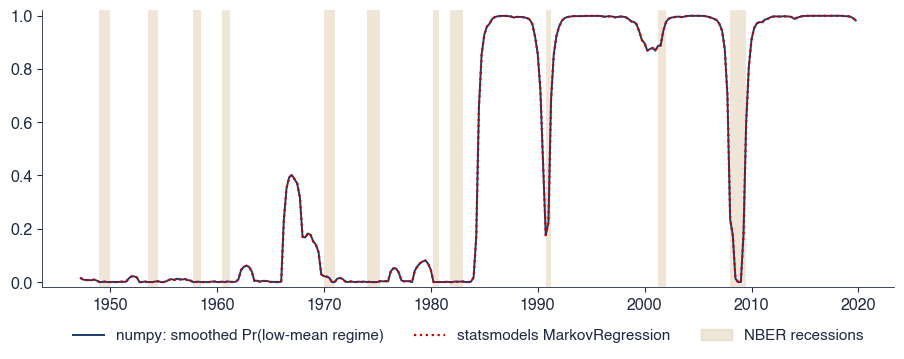

{'T': 291, 'em_ll': -348.57012963018894, 'em_iters': 31, 'ml_ll': -348.4963461520396, 'sm_ll': -348.496346187033, 'mu': [0.7428639577313313, 0.8079008401112012], 'sd': [0.4399772038043913, 1.1962632398922397], 'P': [0.9745306229529044, 0.9776253567003661], 'se': [0.04442577494945356, 0.09811319988480467, 0.036234268367439884, 0.17210032071139844, 0.019757720180547694, 0.017127433366305046], 'sm_mu': [0.7428665664627806, 0.8078951256588033], 'sm_P': [0.9745262459926279, 0.9776244934673455], 'maxdiff': 4.711400359797002e-05, 'qps': 1.0958241754302471, 'dur': [39.262837019959, 44.693449929383334]}


In [15]:
# Solution
print(b1_numpy_vs_sm(save_it=False))

**Interpretation of the result.** The two implementations agree; the low-mean regime mixes recessions and volatility.

## B2 [Proposed]: Hamilton (1989) on his data and after 1984

**Question.** Does Hamilton's model still find recessions in the Great Moderation? Model: B1.

1. Estimate on Hamilton's data with numpy and statsmodels.
2. Means, persistence, QPS.
3. Re-estimate on 1984–2019.
4. Interpretation: what does the low regime describe after 1984?

**Report:** two log-likelihoods, two sets of five numbers, one share, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: how many regimes in Romanian GDP growth?

**Question.** Is there statistical evidence for regimes in Romanian quarterly GDP growth?

1. Information criteria for K = 1, 2, 3.
2. LR of one against two regimes and its bootstrap p-value.
3. Bootstrap 95% quantile against the chi-square value.
4. Interpretation: which quarters form the low regime?

**Report:** a table of nine criteria, one LR and one p-value, two quantiles, a list of quarters, one sentence.

- B = 49 here (199 on the slides).

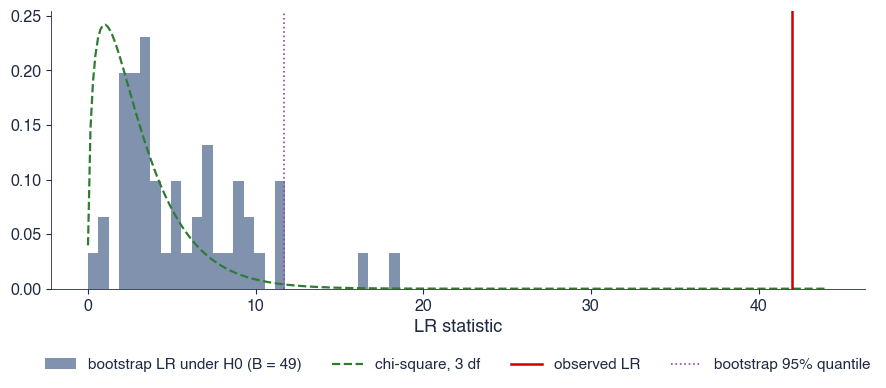

{'T': 125, 'start': '1995Q2', 'end': '2026Q2', 'ic': {'1': {'loglik': -303.5161877867485, 'npar': 2, 'AIC': 611.032375573497, 'BIC': np.float64(616.6890030481017), 'HQ': np.float64(613.3303647094779)}, '2': {'loglik': -282.50906099448844, 'npar': 6, 'AIC': 577.0181219889769, 'BIC': np.float64(593.9880044127907), 'HQ': np.float64(583.9120893969196)}, '3': {'loglik': -275.9495003986193, 'npar': 12, 'AIC': 575.8990007972386, 'BIC': np.float64(609.8387656448663), 'HQ': np.float64(589.6869356131239)}}, 'LR': 42.014253584520134, 'p': 0.02, 'q95': 11.699002822232137, 'c3': 7.8147279032511765, 'mu': [0.03386946930464417, 1.0376132938764546], 'sd': [3.923703953112481, 1.310336256846164], 'P': [0.9004792803176854, 0.9433193543122285], 'B': 49, 'lo_q': ['1995Q2', '1995Q3', '1995Q4', '1996Q1', '1996Q2', '1996Q3', '1996Q4', '1997Q1', '1997Q2', '1997Q3', '1997Q4', '1998Q1', '1998Q2', '1998Q3', '1998Q4', '1999Q1', '1999Q2', '1999Q3', '1999Q4', '2000Q1', '2000Q2', '2000Q3', '2000Q4', '2001Q1', '2003Q4

In [17]:
# Solution
print(b3_ro_regimes(save_it=False, B=49))

**Interpretation of the result.** The regimes separate a volatile era with deep falls from stable growth.

## B4 [Proposed]: Romanian inflation regimes

**Question.** Do the inflation regimes differ only in level and volatility, or also in persistence? Model: B3.

1. MSIH(3)-AR(1) and MSIAH(3)-AR(1).
2. Log-likelihoods, BIC, levels, AR coefficients, durations.
3. Filtered probabilities at the end of the sample.
4. Interpretation: which model for 2027?

**Report:** two log-likelihoods and BICs, two sets of levels, coefficients and durations, two probability vectors, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: bull and bear regimes of the S&P 500 and the BET

**Question.** Are the turbulent regimes of the US and Romanian equity markets synchronised?

1. Two regimes for each index.
2. Means, volatilities, durations, turbulent share.
3. Correlation of the turbulent probabilities; maxima in 2008, 2020, 2022.
4. Interpretation: are BET regimes imported?

**Report:** a table, one correlation, six probabilities, one sentence.

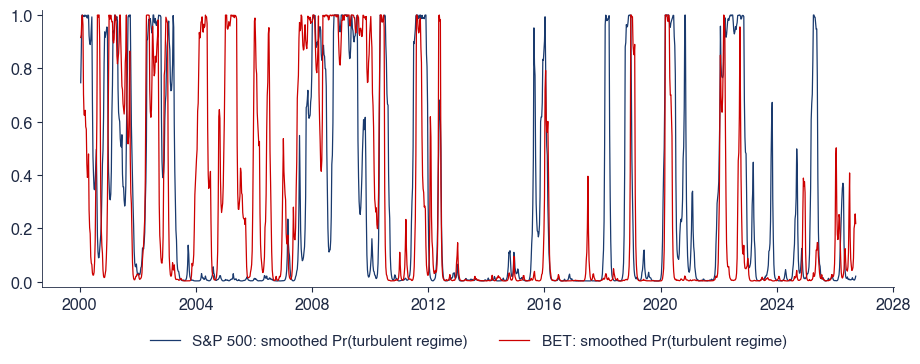

{'sp500': {'mu': [16.62495195859994, -20.551270245113642], 'sd': [10.923319007186093, 28.335214090050354], 'P': [0.9728119644750562, 0.9304202392582427], 'dur': [36.78088470505884, 14.371995381120419], 'share': 0.26202440775305097, 'T': 1393}, 'bet': {'mu': [20.121361644395186, 3.184513323783177], 'sd': [13.641741015745868, 39.93114921969202], 'P': [0.9693291216567098, 0.9177701420961446], 'dur': [32.6042178775349, 12.161032810846125], 'share': 0.25380710659898476, 'T': 1379}, 'corr': 0.47882675585178974, 'both': 0.14865844815083393, 'bet_only': 0.10514865844815083, 'p2008': [0.9999999999999973, 0.9999999999999997], 'p2020': [0.9999999999999978, 0.9999999999999999], 'p2022': [0.999996925208135, 0.9999999961571943]}


In [19]:
# Solution
print(b5_bullbear(save_it=False))

**Interpretation of the result.** The big global episodes are shared, but part of the BET turbulence is domestic.

## B6 [Proposed]: MS-GARCH for the BET

**Question.** How much of the GARCH persistence of the BET is regime persistence? Model: B5, A7.

1. GARCH(1,1) and MS-GARCH (HMP).
2. Persistences, transition probabilities, volatilities, BIC.
3. Share of high-volatility days.
4. Interpretation: a 10-day volatility forecast after a calm month.

**Report:** two BICs, three persistences, two probabilities, two volatilities, one share, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: EUR/RON in 2025, a new regime or a break?

**Question.** Was the depreciation of May 2025 the start of a new volatility regime, a level shift, or both? Model: B5.

1. A five-line pre-registration.
2. Two-regime model on daily changes 2023–2026; volatilities, durations, shares.
3. Interpretation: what can one episode tell?

**Report:** a five-line plan, a table of six numbers, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) the smoothed probabilities show what a forecaster knew in real time;
- (b) with p11 = 0.9 and p22 = 0.75, the ergodic probability of regime 1 is 0.9;
- (c) to test one regime against two, compare LR with a chi-square with 4 degrees of freedom;
- (d) EM always reaches the global maximum because each step increases the likelihood;
- (e) Hamilton's MSM-AR(4) with two regimes needs a filter over 32 states;
- (f) Gray's MS-GARCH is exact, Haas–Mittnik–Paolella approximates the path;
- (g) a positive GPH estimate of d proves long memory rather than regime switching.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
